# **Identitas**
## Tugas 1 CVI
## Oleh: Aloysius Pijar Hutama Indrianto
## NIM: 24/534591/PA/22675

**CATATAN:
File dataset gambar yang digunakan pada notebook ini dapat diakses pada github repo assignment 1.**

# Dependencies

Dependencies harus dijalankan sebelum menjalankan blok kode lainnya. Jika tidak dijalankan, maka kode lainnya tidak akan berjalan sebagaimana mestinya.

In [ ]:
#import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# High Contrast

Kita akan menyelesaikan problem High Contrast dengan menggunakan Contrast Stretching dan Histogram Equalization. Perhatikan bahwa untuk setiap metode (dan seterusnya), kita akan mencoba membuat fungsinya sendiri tanpa menggunakan library bawaan seperti equalize_hist.

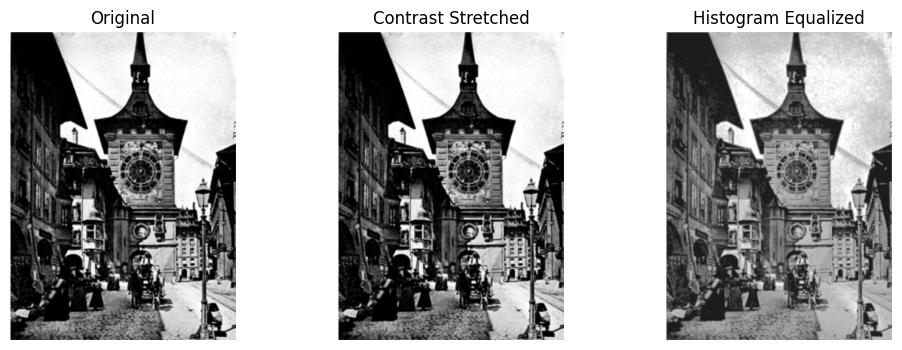

In [ ]:
#high contrast image (Contrast stretching or Histogram equalization)

image = cv2.imread('highcontrast.png')

#using contrast stretching
def contrast_stretching(image):
    a = 0
    b = 255
    min_val = np.min(image)
    max_val = np.max(image)
    stretched = (image - min_val) * ((b-a) / (max_val - min_val))
    return stretched.astype(np.uint8)

#using histogram equalization
def histogram_equalization(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.shape[0] * gray.shape[1]
    freq = np.bincount(gray.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    equalized_gray = map_values[gray]
    return cv2.cvtColor(equalized_gray, cv2.COLOR_GRAY2BGR)

# apply enhancements
stretched = contrast_stretching(image)
equalized = histogram_equalization(image)

# show original and enhanced versions
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(stretched, cv2.COLOR_BGR2RGB))
plt.title('Contrast Stretched')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(equalized, cv2.COLOR_BGR2RGB))
plt.title('Histogram Equalized')
plt.axis('off')

plt.show()


Dapat dilihat bahwa Histogram Equalization memberikan hasil yang lebih terlihat jika dibandingkan dengan contrast stretching.

# Low Contrast

Kita akan menyelesaikan problem Low Contrast dengan menggunakan Contrast Stretching dan Histogram Equalization.

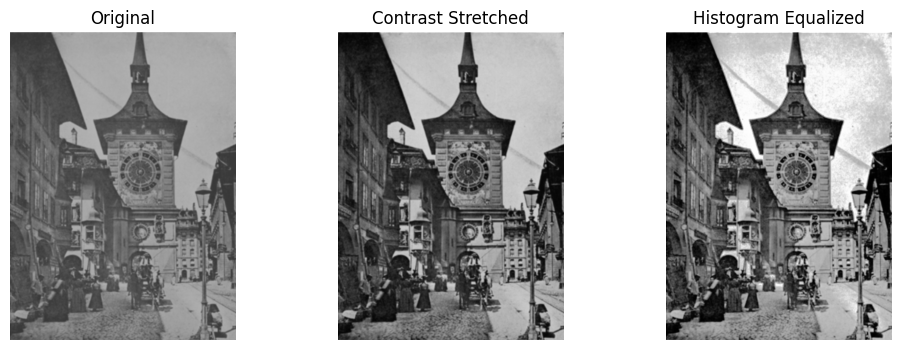

In [ ]:
#low contrast image (Contrast stretching or Histogram equalization)

image = cv2.imread('lowcontrast.png')

#using contrast stretching
def contrast_stretching(image):
    a = 0
    b = 255
    min_val = np.min(image)
    max_val = np.max(image)
    stretched = (image - min_val) * ((b-a) / (max_val - min_val))
    return stretched.astype(np.uint8)

#using histogram equalization
def histogram_equalization(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    total_pixels = gray.shape[0] * gray.shape[1]
    freq = np.bincount(gray.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    equalized_gray = map_values[gray]
    return cv2.cvtColor(equalized_gray, cv2.COLOR_GRAY2BGR)

# apply enhancements
stretched = contrast_stretching(image)
equalized = histogram_equalization(image)

# show original and enhanced versions
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(stretched, cv2.COLOR_BGR2RGB))
plt.title('Contrast Stretched')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(equalized, cv2.COLOR_BGR2RGB))
plt.title('Histogram Equalized')
plt.axis('off')
plt.show()

Dapat dilihat bahwa baik contrast stretching maupun histogram equalization memberikan hasil yang lebih baik daripada gambar originalnya. Contrast stretching memberikan hasil yang lebih shadowy dan detailed daripada histogram equalization.

# Noisy Image

Kita akan menyelesaikan problem Noisy Image dengan menggunakan Mean Filter. Ukuran kernel yang digunakan adalah 3x3

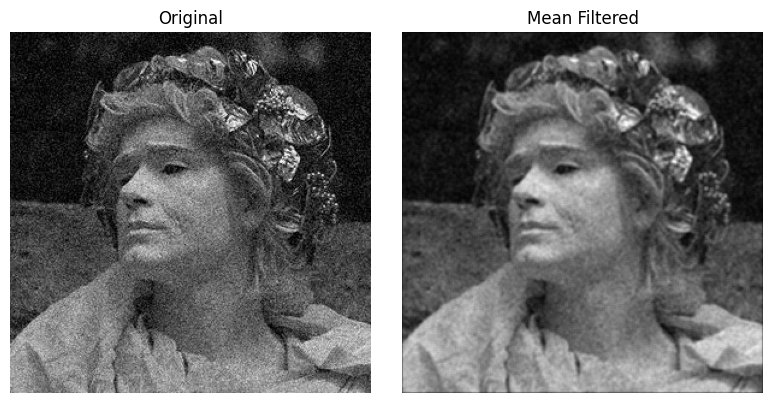

In [ ]:
image = cv2.imread('noise2.jpg', cv2.IMREAD_GRAYSCALE)
kernel_size = 3

# Fungsi Bantuan: Zero Padding
def apply_zero_padding(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size), dtype=np.float32)
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

#using mean filter
def mean_filter(image, kernel_size):
    pad_size = kernel_size // 2
    padded_img = apply_zero_padding(image, pad_size)
    output_img = np.zeros_like(image, dtype=np.float32)

    kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded_img[i:i+kernel_size, j:j+kernel_size]
            output_img[i, j] = np.sum(window * kernel)

    return np.clip(output_img, 0, 255).astype(np.uint8)


# apply filters
mean_filtered = mean_filter(image, kernel_size)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filtered')
plt.axis('off')

plt.tight_layout()
plt.show()

Dapat dilihat bahwa mean filter berhasil mengurangi noise yang ada pada gambar original. Hasil yang diberikan adalah gambar yang lebih smooth dan less noisy.

# Dark Image

Kita akan menyelesaikan problem Dark Image dengan menggunakan Histogram Equalization dan log transform.

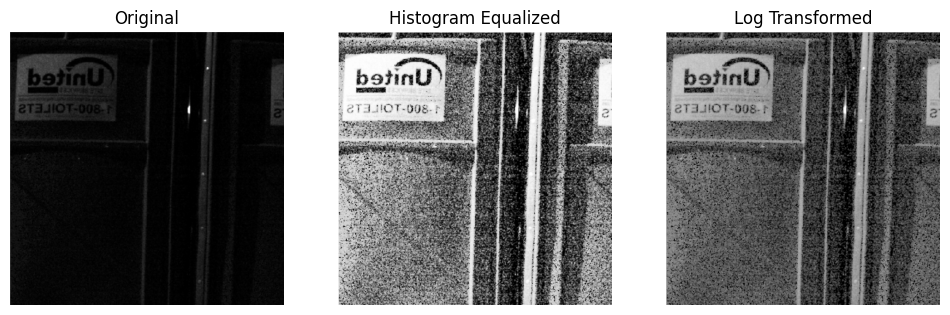

In [ ]:
#dark image (Histogram equalization or log transformation)

import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('toodark.png', cv2.IMREAD_GRAYSCALE)

#using histogram equalization
def histogram_equalization(image):
    total_pixels = image.shape[0] * image.shape[1]
    freq = np.bincount(image.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    equalized_gray = map_values[image]
    return equalized_gray

# using log transformation
def log_transformation(image):
    max_val = float(np.max(image))
    c = 255 / np.log(1 + max_val)
    log_image = c * np.log(1 + image.astype(np.float32))
    return np.uint8(log_image)

# apply enhancements
equalized = histogram_equalization(image)
log_transformed = log_transformation(image)

# show original and enhanced versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
# HAPUS cvtColor di sini
plt.imshow(equalized, cmap='gray')
plt.title('Histogram Equalized')
plt.axis('off')

plt.subplot(1, 3, 3)
# HAPUS cvtColor di sini
plt.imshow(log_transformed, cmap='gray')
plt.title('Log Transformed')
plt.axis('off')

plt.show()

Dapat dilihat bahwa baik Histogram equalization maupun log transformation memberikan hasil gambar yang jauh lebih detailed dan terang. Log transform memberikan hasil yang lebih rata dan less noisy jika dibandingkan dengan histogram equalization.

# Bright Image

Kita akan menyelesaikan problem Bright Image dengan menggunakan Histogram Equalization dan Exponential Transform.

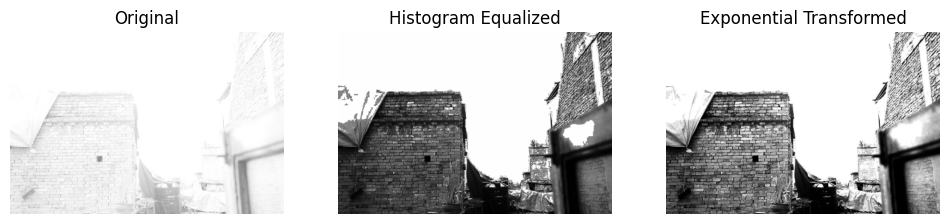

In [ ]:
#bright image (Histogram equalization or exponential transformation)

image = cv2.imread('toobright2.jpg', cv2.IMREAD_GRAYSCALE)

#using histogram equalization
def histogram_equalization(image):
    total_pixels = image.shape[0] * image.shape[1]
    freq = np.bincount(image.flatten(), minlength=256)
    p_l = freq / total_pixels
    c_p = np.cumsum(p_l)
    map_values = np.floor(c_p * 255).astype(np.uint8)
    equalized_gray = map_values[image]
    return equalized_gray

#using exponential transformation
def power_law_transformation(image, gamma):
    r = image.astype(np.float32) / 255.0
    c = 255.0
    s = c * np.power(r, gamma)
    return np.uint8(s)

# apply enhancements
equalized = histogram_equalization(image)
exp_transformed = power_law_transformation(image, gamma=15)

# show original and enhanced versions
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(equalized, cv2.COLOR_BGR2RGB))
plt.title('Histogram Equalized')
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(exp_transformed, cv2.COLOR_BGR2RGB))
plt.title('Exponential Transformed')
plt.axis('off')
plt.show()

Dapat dilihat bahwa baik histogram equalization maupun exponential transformation memberikan hasil gambar yang jauh lebih detailed. Pada kasus ini, histogram equalization memberikan hasil gambar yang sedikit lebih gelap dan kontras jika dibandingkan dengan exponential transformation.

# Blurred Image

Kita akan menyelesaikan problem Blurred Image dengan menggunakan Laplacian Filter.

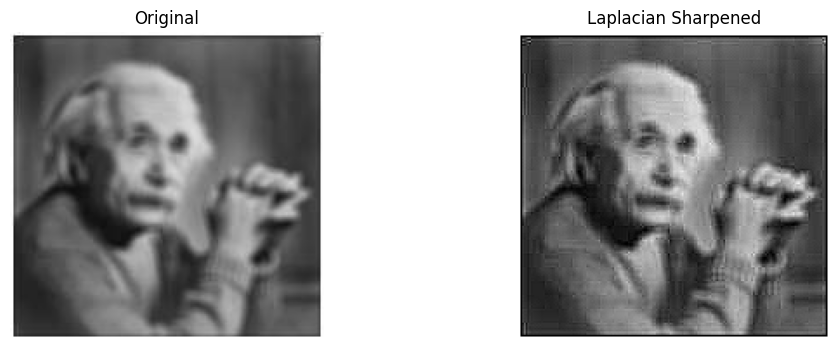

In [ ]:
#blurred image (sharpening with laplacian filter)

import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('blur2.jpg')

def custom_laplacian_sharpening(image):
    kernel = np.array([[ 0,  1,  0],
                       [ 1, -4,  1],
                       [ 0,  1,  0]], dtype=np.float32)

    kernel_size = 3
    pad_size = kernel_size // 2
    output_laplacian = np.zeros_like(image, dtype=np.float32)

    if len(image.shape) == 3:
        # Jika gambar berwarna (3 channel: B, G, R)
        padded_img = np.zeros((image.shape[0] + 2*pad_size, image.shape[1] + 2*pad_size, 3), dtype=np.float32)
        padded_img[pad_size:-pad_size, pad_size:-pad_size, :] = image
        for c in range(3):
            for i in range(image.shape[0]):
                for j in range(image.shape[1]):
                    window = padded_img[i:i+kernel_size, j:j+kernel_size, c]
                    output_laplacian[i, j, c] = np.sum(window * kernel)
    else:
        # Jika gambar grayscale (1 channel)
        padded_img = np.zeros((image.shape[0] + 2*pad_size, image.shape[1] + 2*pad_size), dtype=np.float32)
        padded_img[pad_size:-pad_size, pad_size:-pad_size] = image

        for i in range(image.shape[0]):
            for j in range(image.shape[1]):
                window = padded_img[i:i+kernel_size, j:j+kernel_size]
                output_laplacian[i, j] = np.sum(window * kernel)
    sharpened = image.astype(np.float32) - output_laplacian
    return np.clip(sharpened, 0, 255).astype(np.uint8)

# apply enhancements
sharpened = custom_laplacian_sharpening(image)

# show original and sharpened versions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB))
plt.title('Laplacian Sharpened')
plt.axis('off')
plt.show()

Dapat dilihat bahwa hasil gambar setelah menggunakan laplacian filter ialah gambar yang lebih tajam dibandingkan gambar originalnya. Laplacian filter berhasil memunculkan detail yang sebelumnya tersembunyikan pada gambar pertama oleh blur.

# OverSharpened Image

Kita akan menyelesaikan problem Oversharpened image dengan menggunakan Smoothing with gaussian filter.

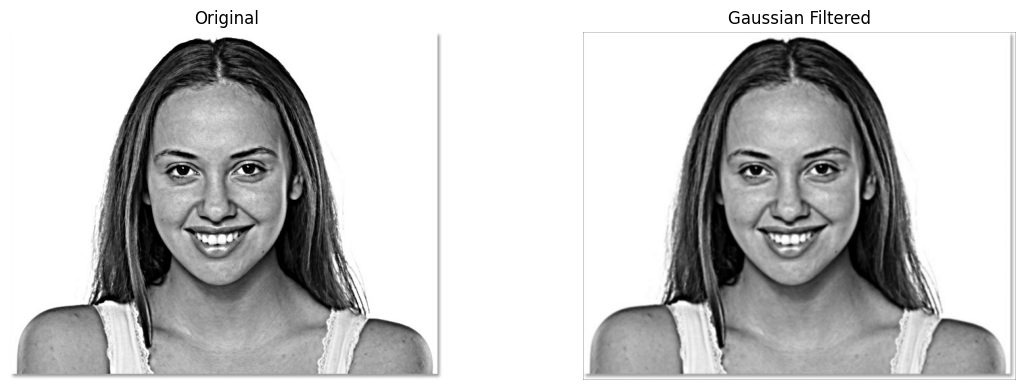

In [ ]:
#too sharp image (smoothing or blurring with Gaussian filter)

image = cv2.imread('oversharpened2.jpg', cv2.IMREAD_GRAYSCALE)
kernel_size = 3

# Fungsi Bantuan: Zero Padding
def apply_zero_padding(image, pad_size):
    padded_image = np.zeros((image.shape[0] + 2 * pad_size, image.shape[1] + 2 * pad_size), dtype=np.float32)
    padded_image[pad_size:-pad_size, pad_size:-pad_size] = image
    return padded_image

#using gaussian filter
def generate_gaussian_kernel(size, sigma):
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            kernel[i, j] = (1.0 / (2.0 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2.0 * sigma**2))

    return kernel / np.sum(kernel)

def gaussian_filter(image, kernel_size, sigma=1.0):
    pad_size = kernel_size // 2
    padded_img = apply_zero_padding(image, pad_size)
    output_img = np.zeros_like(image, dtype=np.float32)

    kernel = generate_gaussian_kernel(kernel_size, sigma)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded_img[i:i+kernel_size, j:j+kernel_size]
            output_img[i, j] = np.sum(window * kernel)

    return np.clip(output_img, 0, 255).astype(np.uint8)

# apply filters
gaussian_filtered = gaussian_filter(image, kernel_size)

# 2. PERBAIKAN: Hapus cvtColor dan tambahkan cmap='gray' untuk visualisasi Matplotlib
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title('Gaussian Filtered')
plt.axis('off')

plt.tight_layout()
plt.show()

Dapat dilihat bahwa gambar yang dihasilkan oleh smoothing ialah gambar yang lebih smooth dan less sharp. Smoothing dengan gaussian filter sukses mengurangi tingkat ketajaman gambar yang terlalu tinggi sebelumnya.